In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


In [59]:
STN_DATA_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
STN_DATA_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
STN_DATA_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
DEL_LIM_ARR = [0.1, 0.2, 0.8, 1.0] 
FILE_PATHS = [STN_DATA_path_PD, STN_DATA_path_std_DBS, STN_DATA_path_sector_DBS]
TYPE = ['PD', 'STD_DBS', 'SECTOR_DBS']
LAT_STRENGTH = 0.0475

In [60]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'igt', 'params.yaml')
params = load_yaml(yaml_path)

In [61]:
TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
NUM_BINS = params['NUM_BINS']
LR = params['LR']
NUM_ARMS = params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']
REW_STD = 0
LOSS_STD = 0

In [62]:
env = IGTEnv(mean_reward=np.array([100,100,50,50])/SCALING_FACTOR,
             std_reward=np.array([REW_STD,REW_STD,REW_STD,REW_STD])/SCALING_FACTOR,
             mean_loss=np.array([-250,-1250,-50,-250])/SCALING_FACTOR,
             std_loss=np.array([LOSS_STD,LOSS_STD,LOSS_STD,LOSS_STD])/SCALING_FACTOR)

In [63]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
IGT_SCORE_MONITOR = defaultdict(dict)
IGT_SE_MONITOR = defaultdict(dict)
LAST_BIN_IGT_SCORE_MONITOR = defaultdict(dict)
LAST_BIN_SE_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
CHOICE_VARIABILITY_METRICS_MONITOR = defaultdict(dict)
Q_ERROR_METRICS_MONITOR = defaultdict(dict)


In [64]:

# ==================================================
# Choice variability and Q-value error metrics for IGT
# ==================================================

import numpy as np
import torch

# True expected net value per deck on normalized reward scale.
# A: 100 + 0.5*(-250) = -25
# B: 100 + 0.1*(-1250) = -25
# C: 50  + 0.5*(-50)  =  25
# D: 50  + 0.1*(-250) =  25
TRUE_IGT_VALUES = np.array([-25, -25, 25, 25], dtype=float) / SCALING_FACTOR


def _to_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    elif hasattr(x, "cpu"):
        x = x.cpu().numpy()
    return np.asarray(x)


def compute_choice_variability_metrics(arm_chosen_monitor, n_arms=4, window_size=15, alpha=0.7):
    """
    Computes choice variability from action choices.
    entropy + switching = alpha * normalized entropy + (1-alpha) * switching rate
    """
    choices = _to_numpy(arm_chosen_monitor).astype(int)

    if choices.ndim == 1:
        choices = choices[None, :]

    epochs, trials = choices.shape
    window_size = min(window_size, trials)

    entropy_by_epoch = []
    switching_by_epoch = []
    combined_by_epoch = []

    for e in range(epochs):
        entropy_windows = []
        switching_windows = []
        combined_windows = []

        for start in range(0, trials - window_size + 1):
            end = start + window_size
            w = choices[e, start:end]

            counts = np.bincount(w, minlength=n_arms).astype(float)
            probs = counts / np.sum(counts)
            probs = probs[probs > 0]

            entropy = -np.sum(probs * np.log(probs)) / np.log(n_arms)
            switching = np.mean(w[1:] != w[:-1]) if len(w) > 1 else 0.0
            combined = alpha * entropy + (1 - alpha) * switching

            entropy_windows.append(entropy)
            switching_windows.append(switching)
            combined_windows.append(combined)

        entropy_by_epoch.append(np.mean(entropy_windows))
        switching_by_epoch.append(np.mean(switching_windows))
        combined_by_epoch.append(np.mean(combined_windows))

    return {
        "window_size": window_size,
        "alpha_entropy": alpha,
        "mean_entropy": float(np.mean(entropy_by_epoch)),
        "mean_switching": float(np.mean(switching_by_epoch)),
        "mean_combined_variability": float(np.mean(combined_by_epoch)),
    }


def dp_monitor_to_array(dp_monitor, n_arms=4):
    """
    Converts dp_monitor from {arm: tensor(epochs, trials, 1)} to array(epochs, trials, arms).
    """
    q_list = []
    for arm in range(n_arms):
        q_arm = _to_numpy(dp_monitor[arm])
        q_arm = np.squeeze(q_arm)
        if q_arm.ndim == 1:
            q_arm = q_arm[None, :]
        q_list.append(q_arm)

    return np.stack(q_list, axis=-1)


def compute_q_error_metrics(dp_monitor, true_values, n_arms=4):
    """
    Computes Q-value error by comparing DP values to true expected deck values.
    true_values should be on the same normalized scale as dp_monitor.
    """
    q_values = dp_monitor_to_array(dp_monitor, n_arms=n_arms)  # epochs x trials x arms
    true_values = np.asarray(true_values, dtype=float).reshape(1, 1, n_arms)

    q_err = q_values - true_values
    q_rmse_by_trial = np.sqrt(np.mean(q_err ** 2, axis=-1))
    q_mae_by_trial = np.mean(np.abs(q_err), axis=-1)

    q_best = np.argmax(q_values, axis=-1)
    true_best_arms = np.where(np.asarray(true_values).reshape(-1) == np.max(true_values))[0]
    q_best_arm_agreement = np.isin(q_best, true_best_arms).astype(float)

    return {
        "true_values": np.asarray(true_values).reshape(-1),
        "mean_q_rmse": float(np.mean(q_rmse_by_trial)),
        "mean_q_mae": float(np.mean(q_mae_by_trial)),
        "mean_q_best_arm_agreement": float(np.mean(q_best_arm_agreement)),
    }


In [65]:
t = 0
for file_path in tqdm(FILE_PATHS):
    print(f'Running: {TYPE[t]}')
    args = load_yaml(file_path)
    args['lat_strength_stn'] = LAT_STRENGTH
    save_temp_path = os.path.join(project_root, 'temp', 'temp.yaml')
    save_yaml(args, save_temp_path)
    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, _ = train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = NUM_BINS,
                                                      STN_data = save_temp_path, 
                                                      d1_amp=0.5, #1,
                                                      d2_amp=0.01, #0.0029,
                                                      gpi_threshold=0.15,
                                                      max_gpi_iters=50, 
                                                      del_lim = del_lim,
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
    
        ARM_MONITOR[TYPE[t]][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[TYPE[t]][del_lim] = reward_monitor
        DP_MONITOR[TYPE[t]][del_lim] = dp_monitor

        # ------------------------------------------------------------
        # Choice variability and DP/Q-value error metrics
        # ------------------------------------------------------------
        choice_var_metrics = compute_choice_variability_metrics(
            arm_chosen_monitor=arm_chosen_monitor,
            n_arms=NUM_ARMS,
            window_size=15,
            alpha=0.7,
        )

        q_error_metrics = compute_q_error_metrics(
            dp_monitor=dp_monitor,
            true_values=TRUE_IGT_VALUES,
            n_arms=NUM_ARMS,
        )

        CHOICE_VARIABILITY_METRICS_MONITOR[TYPE[t]][del_lim] = choice_var_metrics
        Q_ERROR_METRICS_MONITOR[TYPE[t]][del_lim] = q_error_metrics

        A_picks = avg_counts[0]
        B_picks = avg_counts[1]
        C_picks = avg_counts[2]
        D_picks = avg_counts[3]

        Avg_A_picks = torch.mean(A_picks, dim = 0)
        Avg_B_picks = torch.mean(B_picks, dim = 0)
        Avg_C_picks = torch.mean(C_picks, dim = 0)
        Avg_D_picks = torch.mean(D_picks, dim = 0)

        IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().numpy()
        IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))
        IGT_dev = IGT_dev.squeeze().numpy()

        IGT_SCORE_MONITOR[TYPE[t]][del_lim] = IGT_score
        IGT_SE_MONITOR[TYPE[t]][del_lim] = IGT_dev
        LAST_BIN_IGT_SCORE_MONITOR[TYPE[t]][del_lim] = IGT_score[-1]
        LAST_BIN_SE_MONITOR[TYPE[t]][del_lim] = IGT_dev[-1]

        # print(f'IGT score: {IGT_score} with SE of {IGT_dev}')

    
        print(f'Type: {TYPE[t]} and del_lim = {del_lim}: last bin IGT score = {IGT_score[-1]}')
        print(f"    entropy={choice_var_metrics['mean_entropy']:.3f}, switching={choice_var_metrics['mean_switching']:.3f}, entropy+switching={choice_var_metrics['mean_combined_variability']:.3f}, Q-error={q_error_metrics['mean_q_rmse']:.3f}")
    t +=1 


  0%|          | 0/3 [00:00<?, ?it/s]

Running: PD
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.05358672907460795, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

...

Type: SECTOR_DBS and del_lim = 0.8: last bin IGT score = 4.699999809265137
    entropy=0.210, switching=0.070, entropy+switching=0.168, Q-error=0.369
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.3349999999997913, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

Type: SECTOR_DBS and del_lim = 1.0: last bin IGT score = 4.019999980926514
    entropy=0.208, switching=0.067, entropy+switching=0.166, Q-error=0.369


In [ ]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR   # [0.1, 0.2, 0.8, 1.0] 

Last_bin_IGT_PD = [LAST_BIN_IGT_SCORE_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED] 
Last_bin_IGT_std_DBS = [LAST_BIN_IGT_SCORE_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_IGT_sector_DBS = [LAST_BIN_IGT_SCORE_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

Last_bin_IGT_se_PD = [LAST_BIN_SE_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED] 
Last_bin_IGT_se_std_DBS = [LAST_BIN_SE_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_IGT_se_sector_DBS = [LAST_BIN_SE_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

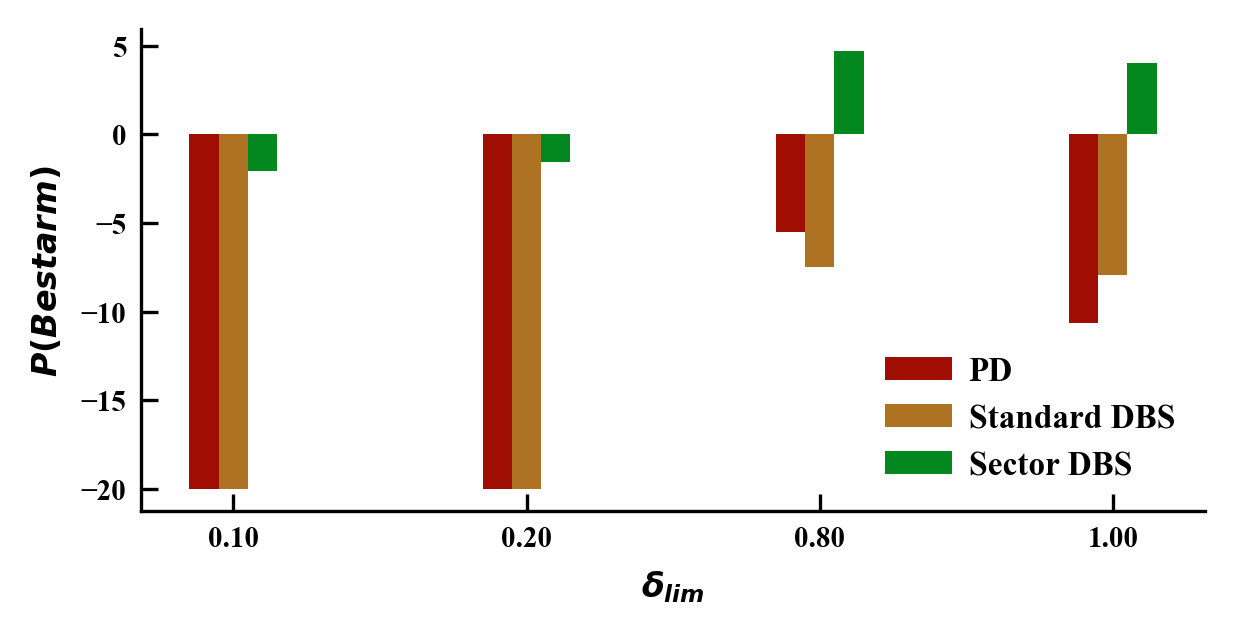

In [67]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}


#+ np.random.randn(len(Last_bin_Probs_std_DBS))*0.01
plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Last_bin_IGT_PD , width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Last_bin_IGT_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Last_bin_IGT_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR_FILTERED], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
# plt.ylim(-0.1, 0.8)
plt.show()

In [68]:

# saving separate pickle for IGT choice-variability and Q-error metrics

def nested_defaultdict_to_dict(d):
    if isinstance(d, defaultdict):
        d = dict(d)
    if isinstance(d, dict):
        return {k: nested_defaultdict_to_dict(v) for k, v in d.items()}
    return d

metrics_data = {
    'DEL_LIM_ARR': DEL_LIM_ARR,
    'TYPE': TYPE,
    'LAT_STRENGTH': LAT_STRENGTH,
    'SCALING_FACTOR': SCALING_FACTOR,
    'NUM_ARMS': NUM_ARMS,
    'TRIALS': TRIALS,
    'EPOCHS': EPOCHS,
    'NUM_BINS': NUM_BINS,
    'TRUE_IGT_VALUES': TRUE_IGT_VALUES,  # normalized expected net deck values used for DP error
    'TRUE_IGT_VALUES_RAW_REFERENCE': TRUE_IGT_VALUES * SCALING_FACTOR,

    # IGT behavioral outputs
    'LAST_BIN_IGT_SCORE_MONITOR': nested_defaultdict_to_dict(LAST_BIN_IGT_SCORE_MONITOR),
    'IGT_SCORE_MONITOR': nested_defaultdict_to_dict(IGT_SCORE_MONITOR),
    'IGT_SE_MONITOR': nested_defaultdict_to_dict(IGT_SE_MONITOR),
    'LAST_BIN_SE_MONITOR': nested_defaultdict_to_dict(LAST_BIN_SE_MONITOR),

    # Choice variability = entropy + switching
    'CHOICE_VARIABILITY_METRICS_MONITOR': nested_defaultdict_to_dict(CHOICE_VARIABILITY_METRICS_MONITOR),

    # DP/value error controls
    'Q_ERROR_METRICS_MONITOR': nested_defaultdict_to_dict(Q_ERROR_METRICS_MONITOR),

    # Raw monitors included so the metric file is self-contained
    'ARM_MONITOR': nested_defaultdict_to_dict(ARM_MONITOR),
    'DP_MONITOR': nested_defaultdict_to_dict(DP_MONITOR),
    'REWARD_MONITOR': nested_defaultdict_to_dict(REWARD_MONITOR),
}

metrics_file_name = 'igt_choice_q_metrics_lat_' + str(LAT_STRENGTH).replace('.', '_') + '.pkl'
metrics_file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'igt', metrics_file_name)

os.makedirs(os.path.dirname(metrics_file_path), exist_ok=True)
with open(metrics_file_path, 'wb') as f:
    pickle.dump(metrics_data, f)

print("Saved IGT choice/Q metrics file:", metrics_file_path)


Saved IGT choice/Q metrics file: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/simulations/decision_making_tasks/igt/igt_choice_q_metrics_lat_0_0475.pkl


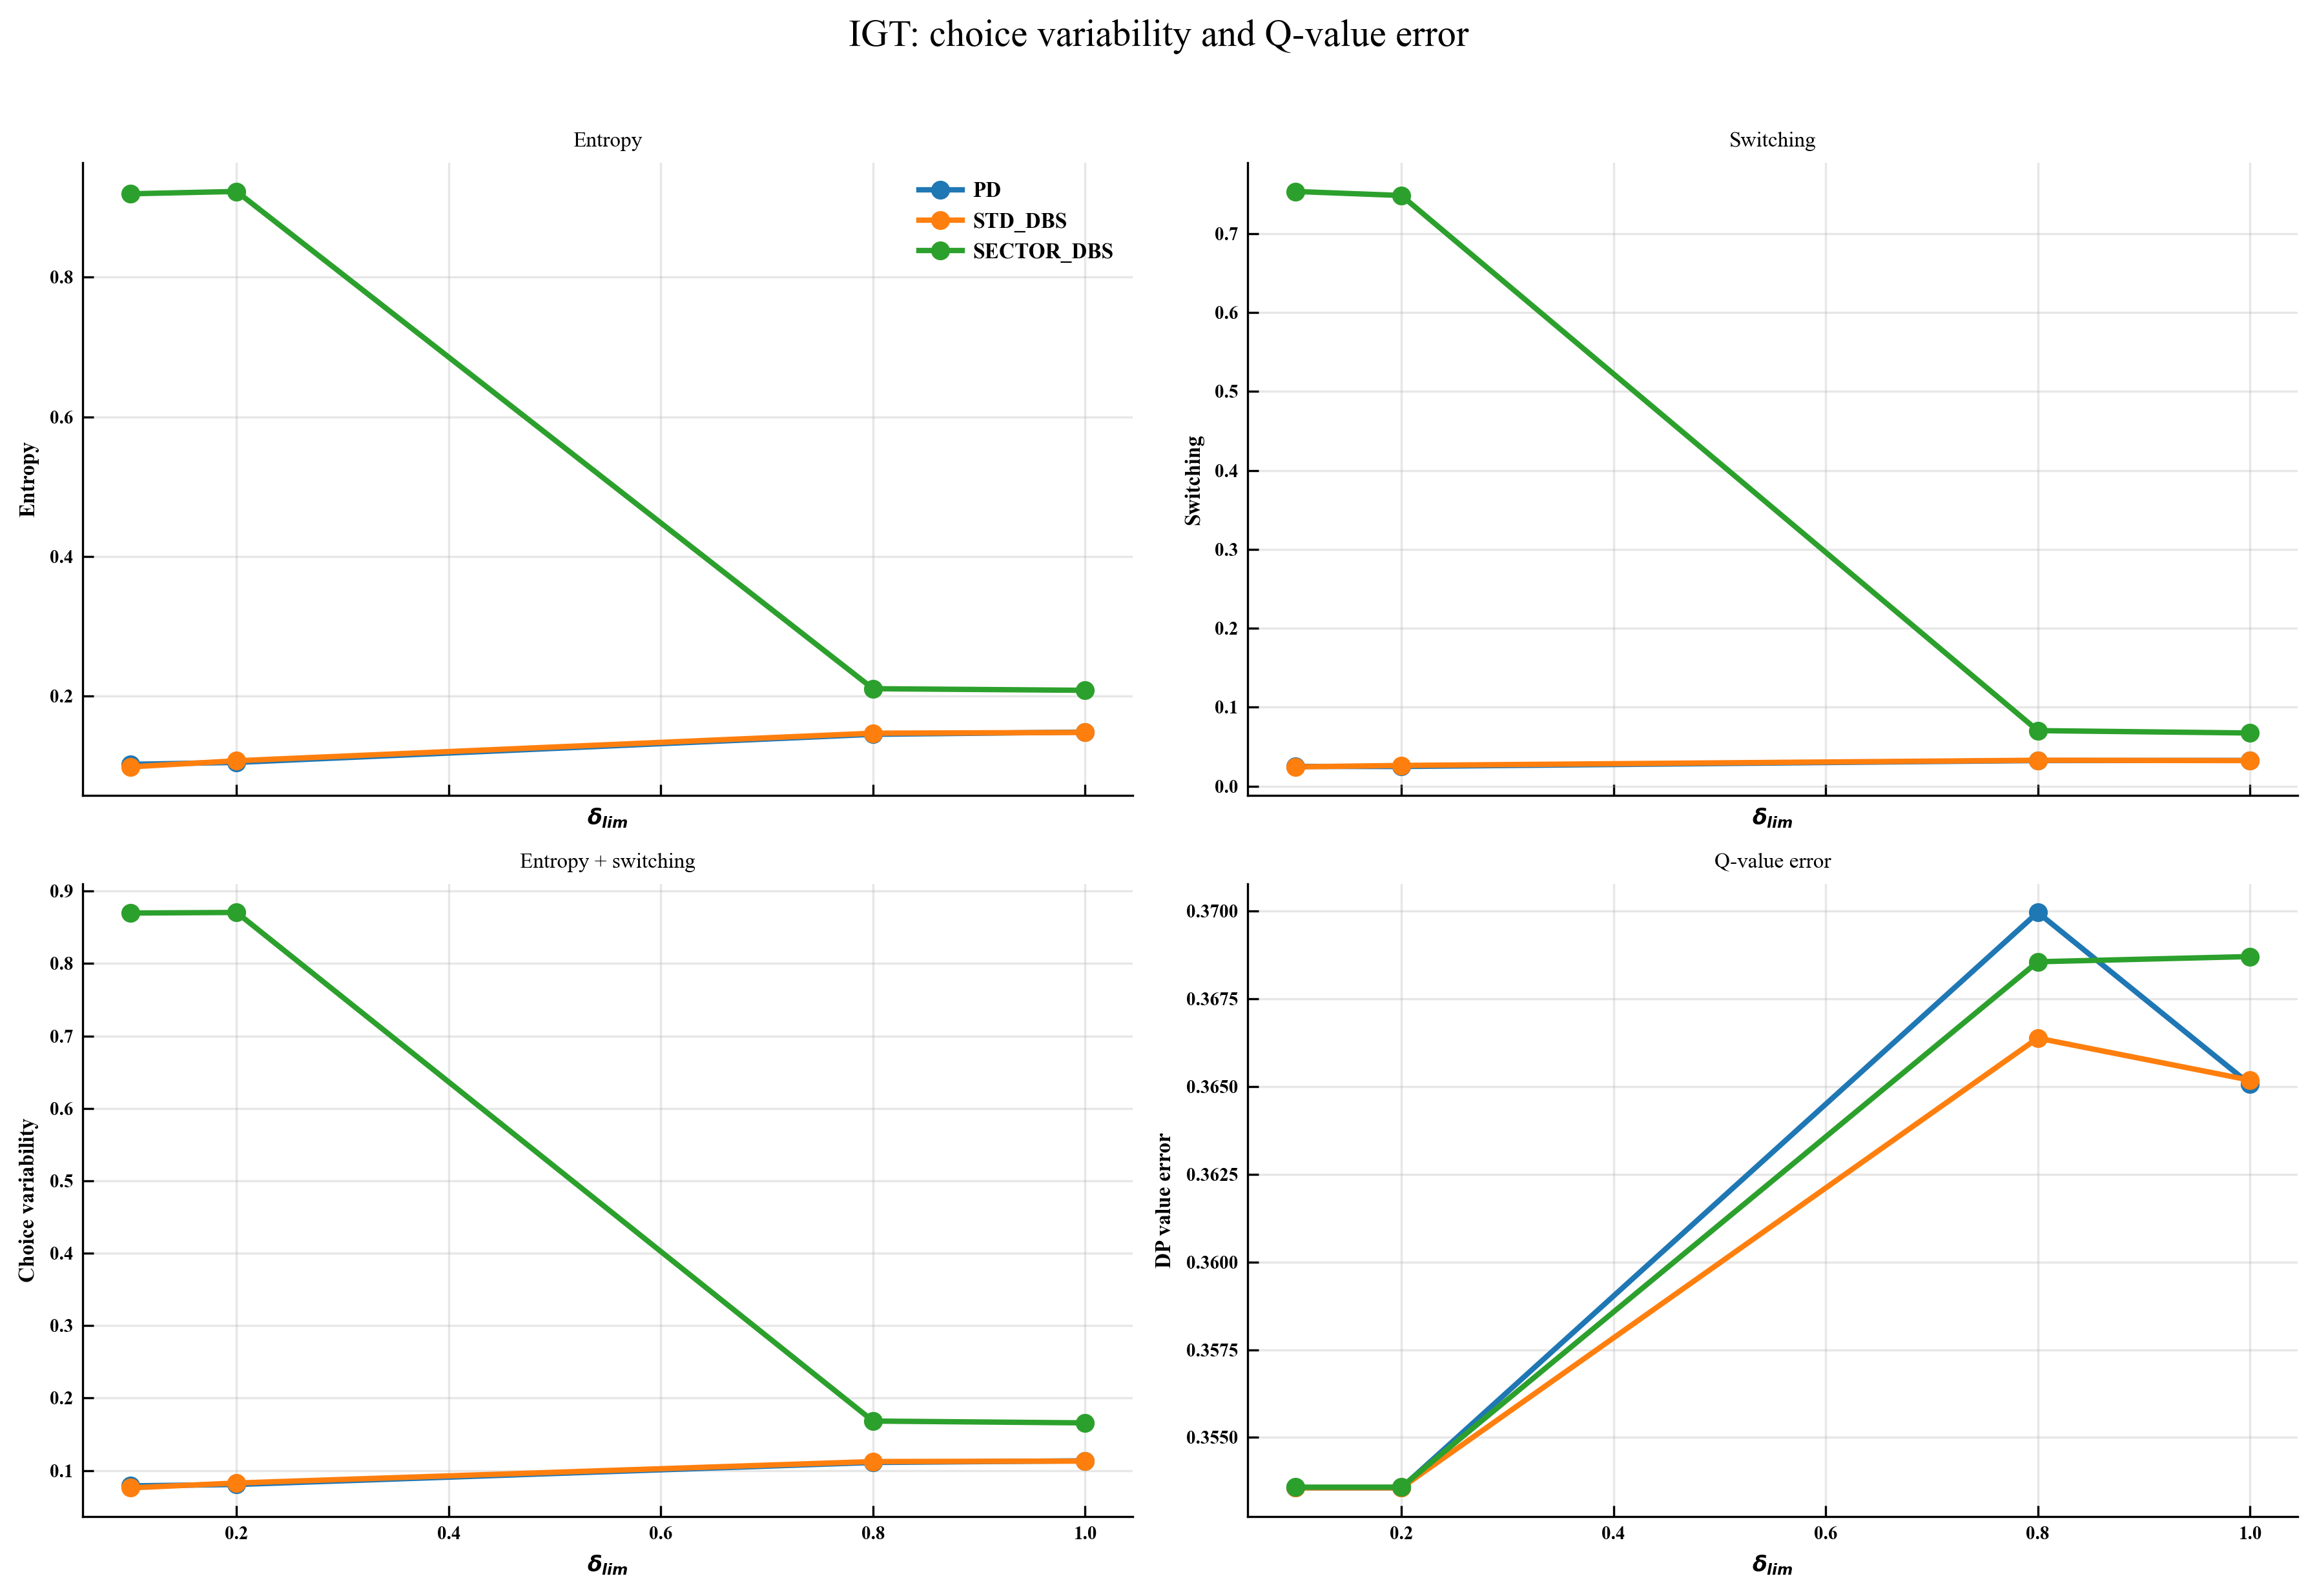

In [ ]:
# ==================================================
# IGT: plot entropy, switching,
# entropy+switching, and Q-value error from loop data
# ==================================================

# Expected existing variables from loop notebook:
# DEL_LIM_ARR
# TYPE
# CHOICE_VARIABILITY_METRICS_MONITOR
# Q_ERROR_METRICS_MONITOR

conditions = TYPE
delta_vals = DEL_LIM_ARR

metric_specs = [
    {
        "title": "Entropy",
        "monitor": CHOICE_VARIABILITY_METRICS_MONITOR,
        "metric_key": "mean_entropy",
        "ylabel": "Entropy"
    },
    {
        "title": "Switching",
        "monitor": CHOICE_VARIABILITY_METRICS_MONITOR,
        "metric_key": "mean_switching",
        "ylabel": "Switching"
    },
    {
        "title": "Entropy + switching",
        "monitor": CHOICE_VARIABILITY_METRICS_MONITOR,
        "metric_key": "mean_combined_variability",
        "ylabel": "Choice variability"
    },
    {
        "title": "Q-value error",
        "monitor": Q_ERROR_METRICS_MONITOR,
        "metric_key": "mean_q_rmse",
        "ylabel": "DP value error"
    },
]


def _to_float(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return float(np.asarray(x))


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for ax, spec in zip(axes, metric_specs):
    for cond in conditions:
        vals = []

        for del_lim in delta_vals:
            val = spec["monitor"][cond][del_lim][spec["metric_key"]]
            vals.append(_to_float(val))

        ax.plot(
            delta_vals,
            vals,
            marker="o",
            linewidth=2,
            markersize=6,
            label=cond
        )

    ax.set_title(spec["title"])
    ax.set_xlabel(r"$\delta_{lim}$")
    ax.set_ylabel(spec["ylabel"])
    ax.grid(True, alpha=0.3)

axes[0].legend(frameon=False)

plt.suptitle("IGT: choice variability and Q-value error", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()# 